In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression,ElasticNet,Ridge,Lasso,LassoCV
from sklearn.preprocessing import normalize
plt.rcParams["figure.figsize"] = (5,4)
plt.rcParams["figure.dpi"] = 150
TICK_SIZE = 12
AXES_SIZE = 14
TITLE_SIZE = 14
FACECOLOR = 'white'
SCATTER_ALPHA = 0.5

plt.rc('font', size=TICK_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=AXES_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXES_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=TICK_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=TICK_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=TICK_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title


In [2]:
# loads data :)
# features are - Average Job Power, Average Job Time, Average Job # Nodes, Number of Jobs, Utilization
#
# average job power and time were calculated as the mean of the mean of the 
# minimum and maximum power and time 
NORMALIZE = True
data_folder = 'numpy_data/'
feature_data = np.load(data_folder + 'sim_features.npy')
feature_qos = np.load(data_folder + 'features_qos.npy')
r_labels = np.load(data_folder + 'r_labels.npy')
p_labels = np.load(data_folder + 'p_labels.npy')
# if normalizing
if NORMALIZE:
    r_labels = r_labels / np.sum(r_labels)
    p_labels = p_labels / np.sum(p_labels)
    feature_data = normalize(feature_data,axis=0)
    feature_qos = normalize(feature_qos,axis=0)
# test train split, I guess
feature_train, feature_test, r_train, r_test = train_test_split(feature_data,r_labels, test_size=0.3, random_state=1)
#print(feature_test)
feature_train, feature_test, p_train, p_test = train_test_split(feature_data,p_labels, test_size=0.3, random_state=1)
#print(feature_test)

In [127]:
# Quantitative Metrics for P/R Linear Regression
### the basic stuff ###
from sklearn.metrics import r2_score
normalization_penalty = 0.00002
#normalization_penalty = 0.00000000000001
p_lin_reg_all = Lasso(alpha=normalization_penalty).fit(feature_qos, p_labels)
r_lin_reg_all = Lasso(alpha=normalization_penalty).fit(feature_qos, r_labels)
p_lin_reg_pred_all = p_lin_reg_all.predict(feature_qos)
r_lin_reg_pred_all = r_lin_reg_all.predict(feature_qos)
print('P MAE:',sklearn.metrics.mean_absolute_error(p_labels,p_lin_reg_pred_all))
print('R MAE:',sklearn.metrics.mean_absolute_error(r_labels,r_lin_reg_pred_all))
print('P R^2:',p_lin_reg_all.score(feature_qos,p_labels))
print('R R^2:',r_lin_reg_all.score(feature_qos,r_labels))
### five fold CV ###
split = 0.3
average_p_r2 = 0
average_r_r2 = 0
trials = 10
for i in range(trials):
    feature_train, feature_test, r_train, r_test = train_test_split(feature_qos,r_labels, test_size=split, random_state=i)
    feature_train, feature_test, p_train, p_test = train_test_split(feature_qos,p_labels, test_size=split, random_state=i)
    p_lin_reg = Lasso(alpha=normalization_penalty).fit(feature_train, p_train)
    #average_p_r2 += p_lin_reg.score(feature_test, p_test)
    average_p_r2 += r2_score(p_lin_reg.predict(feature_test),p_test)
    r_lin_reg = Lasso(alpha=normalization_penalty).fit(feature_train, r_train)
    #average_r_r2 += r_lin_reg.score(feature_test, r_test)
    average_r_r2 += r2_score(r_lin_reg.predict(feature_test),r_test)
print('P 5 CV Mean Test R^2',average_p_r2/trials)
print('R 5 CV Mean Test R^2',average_r_r2/trials)

P MAE: 0.0024782015193173293
R MAE: 0.007401949238050529
P R^2: 0.7929296810148767
R R^2: 0.6759488454576879
P 5 CV Mean Test R^2 -0.2835536882983393
R 5 CV Mean Test R^2 -1.4978171190841056


In [3]:
r_reg_qos = LinearRegression().fit(feature_qos[:,[0,1,-2,-1]], r_labels)
print(r_reg_qos.score(feature_qos[:,[0,1,-2,-1]], r_labels))
r_lin_reg_qos = r_reg_qos.predict(feature_qos[:,[0,1,-2,-1]])


0.6697567832969902


In [62]:
print(feature_qos[:,[0,1,-1]].shape)

(18, 3)


In [4]:
r_reg_no_util = LinearRegression().fit(feature_qos[:,[0,1,-1]], r_labels)
print(r_reg_no_util.score(feature_qos[:,[0,1,-1]], r_labels))
r_lin_reg = r_reg_no_util.predict(feature_qos[:,[0,1,-1]])

0.660890314750859


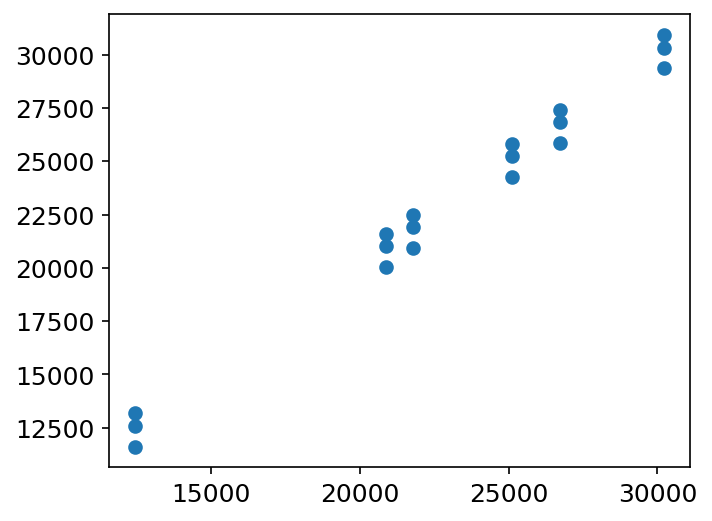

In [66]:
plt.scatter(r_lin_reg,r_lin_reg_qos)

Text(0.5, 1.0, 'R-Prediction Linear Regression Feature Importance')

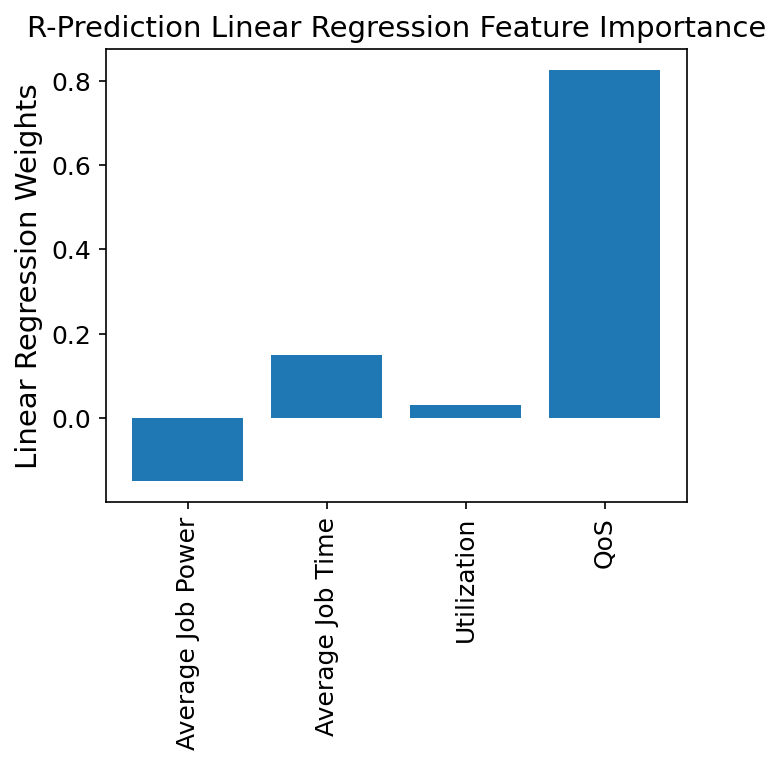

In [43]:
# features are - Average Job Power, Average Job Time, Average Job # Nodes, Number of Jobs, Utilization

#plt.bar(['Average Job Power', 'Average Job Time', 'Average Job # Nodes', 'Number of Jobs', 'Utilization','QoS'],
plt.bar(['Average Job Power', 'Average Job Time','Utilization','QoS'],
        r_reg_qos.coef_)
plt.xticks(rotation=90)
plt.ylabel('Linear Regression Weights')
plt.title('R-Prediction Linear Regression Feature Importance')

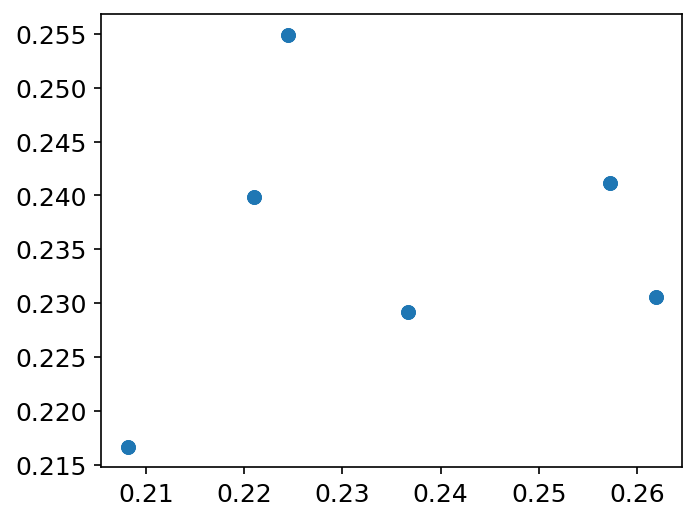

In [38]:
plt.scatter(feature_qos[:,-1],feature_qos[:,0])

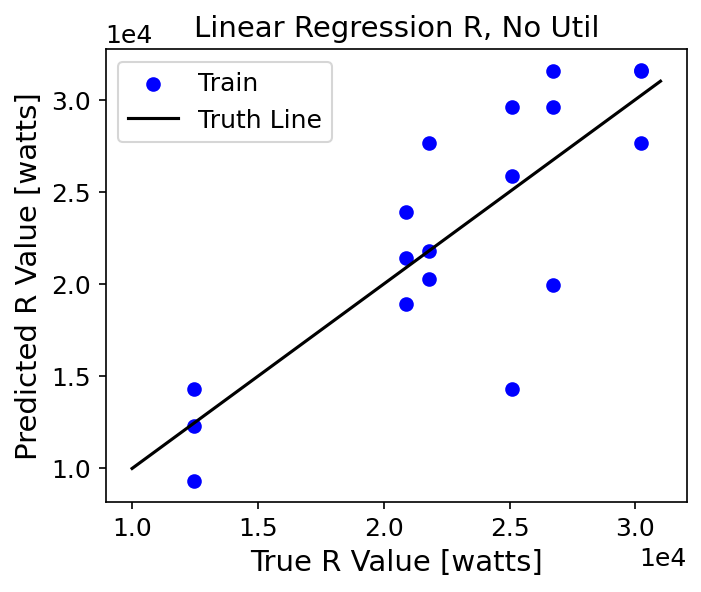

In [28]:
plt.scatter(r_lin_reg,r_labels,color='blue',label='Train')
#plt.scatter(r_lin_reg_qos,r_labels,color='blue',label='Train')

plt.plot([1.0e4,3.1e4], [1.0e4,3.1e4],c='black',label='Truth Line')
plt.legend()
plt.title('Linear Regression R, No Util')
plt.xlabel('True R Value [watts]')
plt.ylabel('Predicted R Value [watts]')

#plt.plot(r_labels, mymodel,c='black',label='Truth Line')
plt.legend()
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

In [3]:
# P using Linear Regression
p_lin_reg = LinearRegression().fit(feature_train, p_train)
print('Train:',p_lin_reg.score(feature_train, p_train))
print('Test:',p_lin_reg.score(feature_test, p_test))
p_pred_linear = p_lin_reg.predict(feature_data)
p_pred_train_linear = p_lin_reg.predict(feature_train)
p_pred_test_linear = p_lin_reg.predict(feature_test)
print(p_lin_reg.coef_)
print(p_lin_reg.intercept_)

Train: 0.8263730020529809
Test: 0.8532908482417613
[641837.60117895  31068.30155488  33075.37270269   9027.64380777
 289421.76602249]
-81577.46425219654


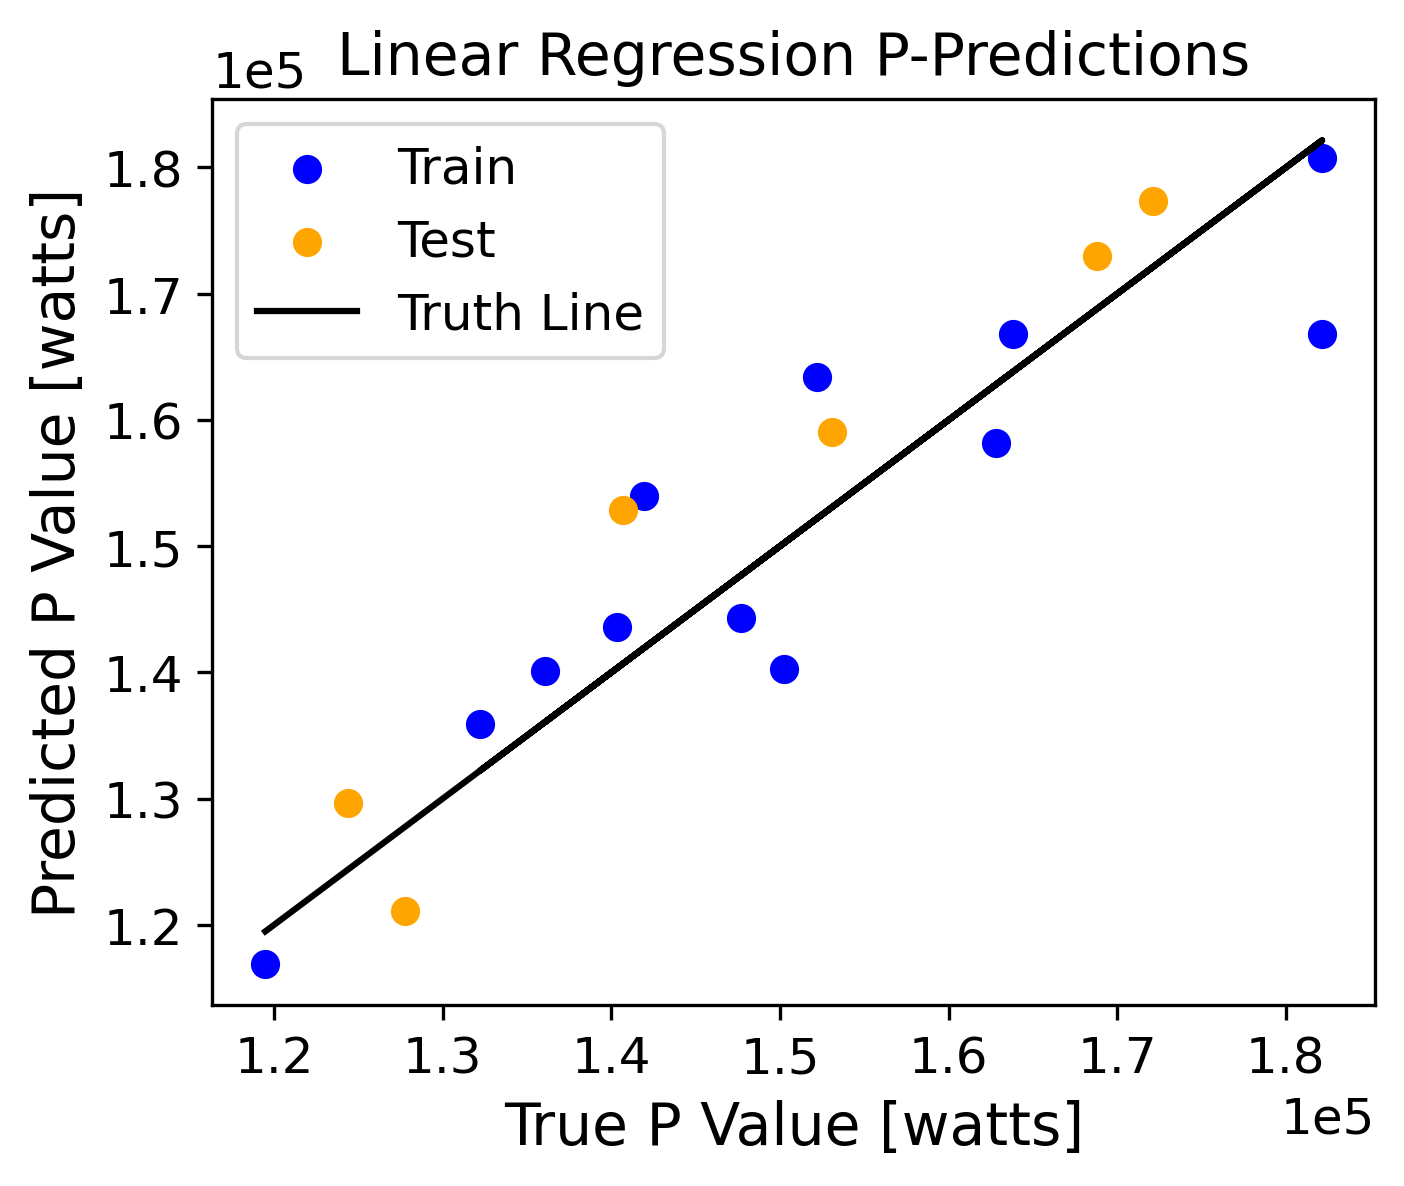

In [75]:
plt.scatter(p_train,p_pred_train_linear,color='blue',label='Train')
plt.scatter(p_test,p_pred_test_linear,color='orange',label='Test')
def myfunc(x):
        return x
mymodel = list(map(myfunc, p_train))
plt.plot(p_train, mymodel,c='black',label='Truth Line')
plt.legend()
plt.title('Linear Regression P-Predictions')
plt.xlabel('True P Value [watts]')
plt.ylabel('Predicted P Value [watts]')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

In [57]:
# R using Kernel Ridge Regression
# 
# Valid values for metric are:
#
#   [‘additive_chi2’, ‘chi2’, ‘linear’, ‘poly’, ‘polynomial’, ‘rbf’, ‘laplacian’, ‘sigmoid’, ‘cosine’]

#r_kernel_ridge = KernelRidge(alpha=0.0001,kernel='rbf').fit(feature_train, r_train)
r_kernel_ridge = KernelRidge(alpha=0.001,kernel='laplacian').fit(feature_train, r_train) # best
#r_kernel_ridge = KernelRidge(alpha=0.00001,kernel='additive_chi2').fit(feature_train, r_train)
#r_kernel_ridge = KernelRidge(alpha=0.00000001,kernel='sigmoid').fit(feature_train, r_train)
#r_kernel_ridge = KernelRidge(alpha=0.0000001,kernel='cosine').fit(feature_train, r_train)

print('Train:',r_kernel_ridge.score(feature_train, r_train))
print('Test:',r_kernel_ridge.score(feature_test, r_test))
r_pred_kernel_test = r_kernel_ridge.predict(feature_test)
r_pred_kernel_train = r_kernel_ridge.predict(feature_train)

Train: 0.9273753020295914
Test: -1.3488909870661652


All: 0.9033695775410653


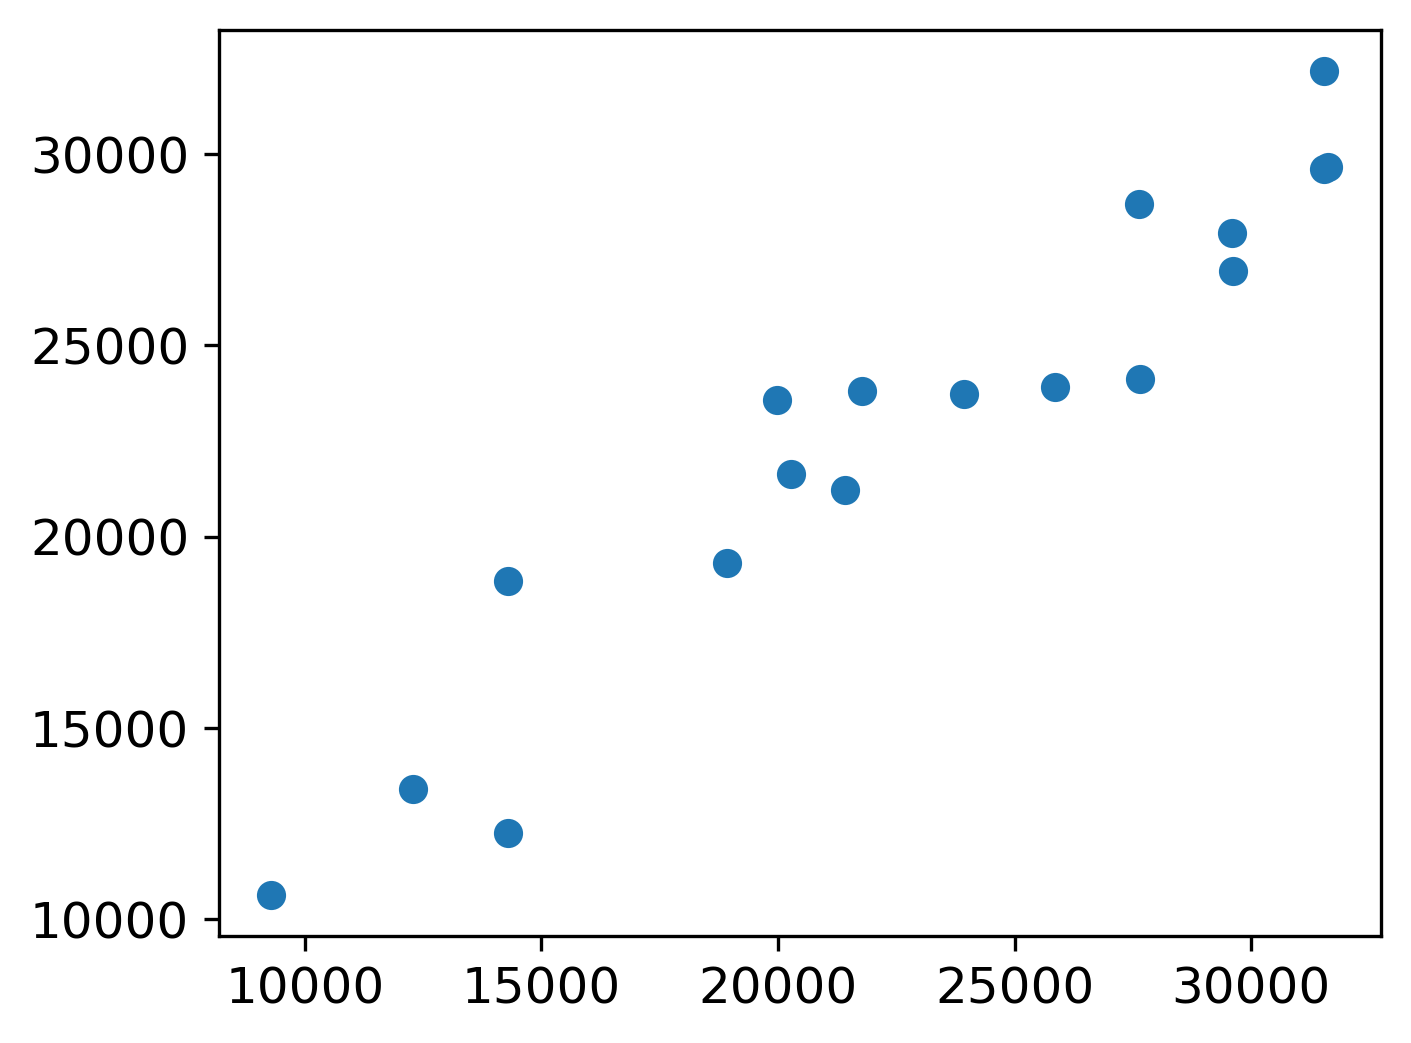

In [90]:
# R using Kernel Ridge Regression, no splitting
# 
r_kernel_ridge = KernelRidge(alpha=0.001,kernel='laplacian').fit(feature_data, r_labels) # best

print('All:',r_kernel_ridge.score(feature_data, r_labels))
r_pred_kernel_all = r_kernel_ridge.predict(feature_data)
plt.scatter(r_labels,r_pred_kernel_all)


Text(0, 0.5, 'Predicted R Value [watts]')

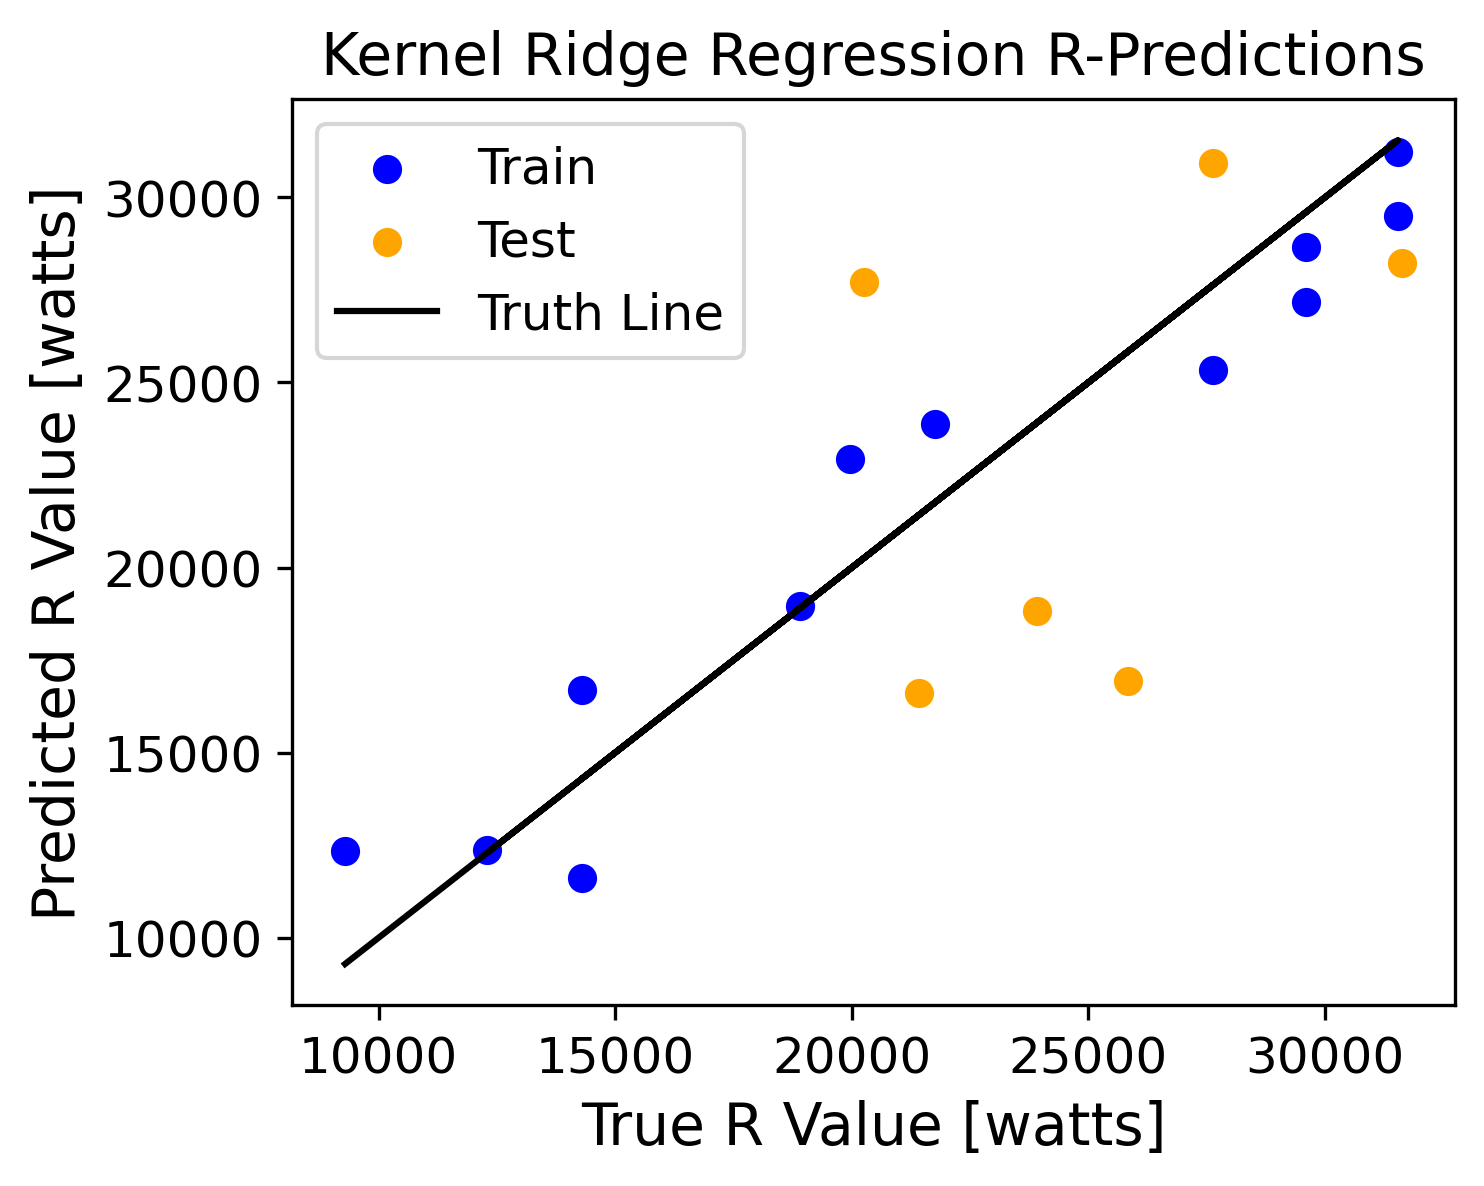

In [76]:
plt.scatter(r_train,r_pred_kernel_train,color='blue',label='Train')
plt.scatter(r_test,r_pred_kernel_test,color='orange',label='Test')
def myfunc(x):
        return x
mymodel = list(map(myfunc, r_train))
plt.plot(r_train, mymodel,c='black',label='Truth Line')
plt.legend()
plt.title('Kernel Ridge Regression R-Predictions')
plt.xlabel('True R Value [watts]')
plt.ylabel('Predicted R Value [watts]')

Text(0.5, 1.0, 'P-Prediction Linear Regression Feature Importance')

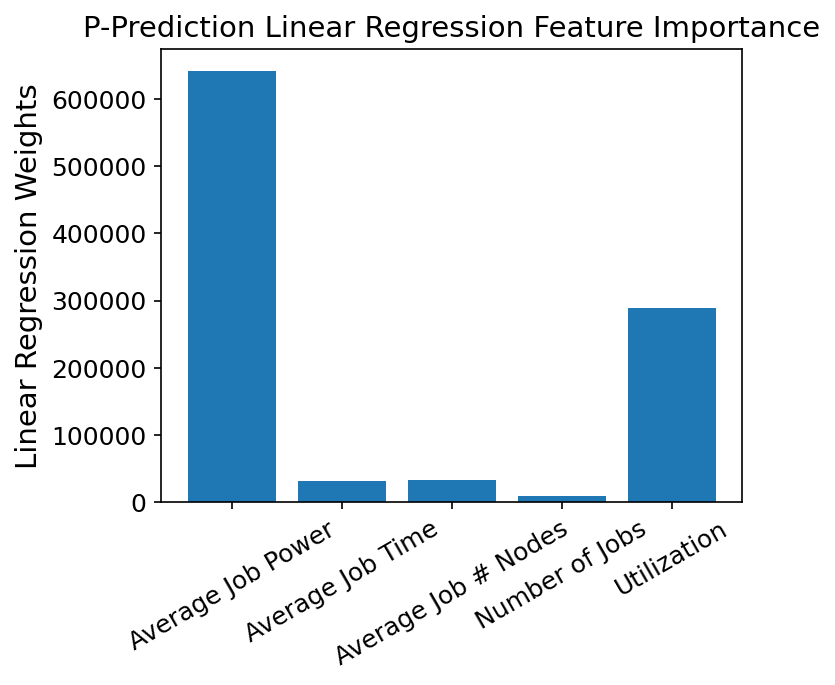

In [13]:
# features are - Average Job Power, Average Job Time, Average Job # Nodes, Number of Jobs, Utilization

plt.bar(['Average Job Power', 'Average Job Time', 'Average Job # Nodes', 'Number of Jobs', 'Utilization'],
        (641837.60117895 , 31068.30155488,  33075.37270269,   9027.64380777, 289421.76602249))
plt.xticks(rotation=30)
plt.ylabel('Linear Regression Weights')
plt.title('P-Prediction Linear Regression Feature Importance')

In [15]:
print(r_reg.coef_)

[ 0.50116295  0.03296652  0.00867294 -0.01395427  0.02974881]
